In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import ast

# =============================================================================
# Path Configuration
# =============================================================================
LEAGUE = 'cg'  # 'cg' = Montenegro 1. CFL | 'srb' = Serbian SuperLiga

DATA_DIR = Path('..') / 'data'
RAW_BASE_DIR = DATA_DIR / 'raw'
PROCESSED_DATA_DIR = DATA_DIR / 'processed' / LEAGUE
OUT_DIR = RAW_BASE_DIR / LEAGUE
RAW_DIR = OUT_DIR / 'raw_by_match'

# =============================================================================
# Load Processed Data
# =============================================================================
print("📂 Loading processed data...")

# Load player and team metadata
players_meta = pd.read_csv(PROCESSED_DATA_DIR / 'players_metadata.csv')
teams_meta = pd.read_csv(PROCESSED_DATA_DIR / 'teams_metadata.csv')
matches_meta = pd.read_csv(PROCESSED_DATA_DIR / 'matches_metadata.csv')
player_stats = pd.read_csv(PROCESSED_DATA_DIR / 'match_player_statistics.csv')

# Create team name mapping
team_name_map = dict(zip(teams_meta['team_id'], teams_meta['team_name']))

print(f"✅ Loaded {len(players_meta)} players, {len(teams_meta)} teams, {len(matches_meta)} matches")

# =============================================================================
# Load Shot Data with xG
# =============================================================================
print("\n📊 Loading shot data for xG analysis...")

shots_all_list = []
for match_dir in RAW_DIR.glob('*'):
    shots_file = match_dir / 'match_shots.csv'
    if shots_file.exists():
        try:
            df = pd.read_csv(shots_file)
            df['match_id'] = int(match_dir.name)
            shots_all_list.append(df)
        except Exception as e:
            print(f"⚠️ Error loading {shots_file}: {e}")

if not shots_all_list:
    raise RuntimeError(f"No shots data found in {RAW_DIR}")

shots_all_df = pd.concat(shots_all_list, ignore_index=True)
print(f"✅ Loaded {len(shots_all_df)} shots from {len(shots_all_list)} matches")

# =============================================================================
# Process Shot Data
# =============================================================================

# Extract goal flag from shotType
shots_all_df['isGoal'] = (shots_all_df['shotType'] == 'goal').astype(int)

# Extract player_id from player column (handle both string and dict formats)
shots_all_df['player_id'] = shots_all_df['player'].apply(
    lambda p: ast.literal_eval(p).get('id') if isinstance(p, str) else (p.get('id') if isinstance(p, dict) else None)
)

# Use processed match_player_statistics for player-team mapping (includes team_name)
player_team_map = player_stats[['match_id', 'player_id', 'team_id', 'team_name']].drop_duplicates()

# Merge shots with team information
shots_all_df = shots_all_df.merge(
    player_team_map,
    on=['match_id', 'player_id'],
    how='left'
)

print(f"✅ Mapped {shots_all_df['team_id'].notna().sum()} shots to teams")

# =============================================================================
# Aggregate Player xG Statistics
# =============================================================================

# Group by player and team (to handle transfers correctly)
player_xg_by_team = (
    shots_all_df
    .groupby(['player_id', 'team_id'], as_index=False)
    .agg(
        Goals=('isGoal', 'sum'),
        xG=('xg', 'sum'),
        team_name=('team_name', 'first')  # Take first team_name for this team_id
    )
)

# Sum Goals and xG across ALL teams (handles mid-season transfers correctly)
player_xg_totals = (
    player_xg_by_team
    .groupby('player_id', as_index=False)
    .agg(Goals=('Goals', 'sum'), xG=('xG', 'sum'))
)

# For team label, use the team the player accumulated most xG with
player_xg_main_team = (
    player_xg_by_team
    .sort_values('xG', ascending=False)
    .drop_duplicates(subset='player_id', keep='first')
    [['player_id', 'team_id', 'team_name']]
    .rename(columns={'team_name': 'Team'})
)

player_xg = player_xg_totals.merge(player_xg_main_team, on='player_id', how='left')

# Add player names
player_xg = player_xg.merge(
    players_meta[['id', 'name']],
    left_on='player_id',
    right_on='id',
    how='left'
).drop(columns=['id'])

player_xg['Diff'] = player_xg['Goals'] - player_xg['xG']

# =============================================================================
# Identify Top Performers
# =============================================================================

MIN_XG = 1.0
TOP_N = 3

# Filter to players with sufficient xG
goals_xg_plot = player_xg[player_xg['xG'] >= MIN_XG].copy()

# Default styling
goals_xg_plot['Color'] = '#555555'
goals_xg_plot['Size'] = 1.0

# Find top over- and under-performers
top_outperformers = goals_xg_plot.nlargest(TOP_N, 'Diff').copy()
top_underperformers = goals_xg_plot.nsmallest(TOP_N, 'Diff').copy()

# Highlight in plot
goals_xg_plot.loc[top_outperformers.index, 'Color'] = 'green'
goals_xg_plot.loc[top_underperformers.index, 'Color'] = 'red'
goals_xg_plot.loc[top_outperformers.index.union(top_underperformers.index), 'Size'] = 3.0

# =============================================================================
# Display Results
# =============================================================================

print('\n✅ Analysis complete!')
print(f'\n🎯 Top {TOP_N} Outperformers (Goals > xG):')
display(top_outperformers[['name', 'Team', 'Goals', 'xG', 'Diff']].round(2))

print(f'\n📉 Top {TOP_N} Underperformers (Goals < xG):')
display(top_underperformers[['name', 'Team', 'Goals', 'xG', 'Diff']].round(2))


📂 Loading processed data...
✅ Loaded 333 players, 10 teams, 130 matches

📊 Loading shot data for xG analysis...
⚠️ Error loading ..\data\raw\cg\raw_by_match\14147344\match_shots.csv: No columns to parse from file
⚠️ Error loading ..\data\raw\cg\raw_by_match\14952691\match_shots.csv: No columns to parse from file
⚠️ Error loading ..\data\raw\cg\raw_by_match\15280997\match_shots.csv: No columns to parse from file
⚠️ Error loading ..\data\raw\cg\raw_by_match\15280999\match_shots.csv: No columns to parse from file
⚠️ Error loading ..\data\raw\cg\raw_by_match\15281000\match_shots.csv: No columns to parse from file
⚠️ Error loading ..\data\raw\cg\raw_by_match\15281001\match_shots.csv: No columns to parse from file
⚠️ Error loading ..\data\raw\cg\raw_by_match\15281002\match_shots.csv: No columns to parse from file
⚠️ Error loading ..\data\raw\cg\raw_by_match\15281008\match_shots.csv: No columns to parse from file
⚠️ Error loading ..\data\raw\cg\raw_by_match\15281009\match_shots.csv: No column

,name,Team,Goals,xG,Diff
47,Armin Bošnjak,FK Arsenal Tivat,5,1.49,3.51
9,Stefan Denković,FK Mornar Bar,8,4.95,3.05
5,Asmir Kajević,FK Dečić Tuzi,6,3.23,2.77



📉 Top 3 Underperformers (Goals < xG):


,name,Team,Goals,xG,Diff
75,Marko Milickovic,FK Budućnost Podgorica,0,3.28,-3.28
88,Petar Vukčević,FK Mornar Bar,0,1.91,-1.91
182,Takeru Komiya,FK Jedinstvo Bijelo Polje,0,1.76,-1.76


# Goals vs Expected Goals (xG) Analysis

This notebook analyzes player performance by comparing actual goals scored vs expected goals (xG) from shot data.

**Data Sources:**
- Shot data from `match_shots.csv` files (includes xG values)
- Player metadata from `players_metadata.csv`

**Analysis:**
- Identifies top **outperformers** (players scoring more than expected)
- Identifies top **underperformers** (players scoring less than expected)
- Creates visualization comparing goals vs xG

✅ Loaded 12 team logos, 257 player photos

✅ Figure saved to: ..\outputs\cg\figures\polutka_lab_goals_vs_xg_post.png


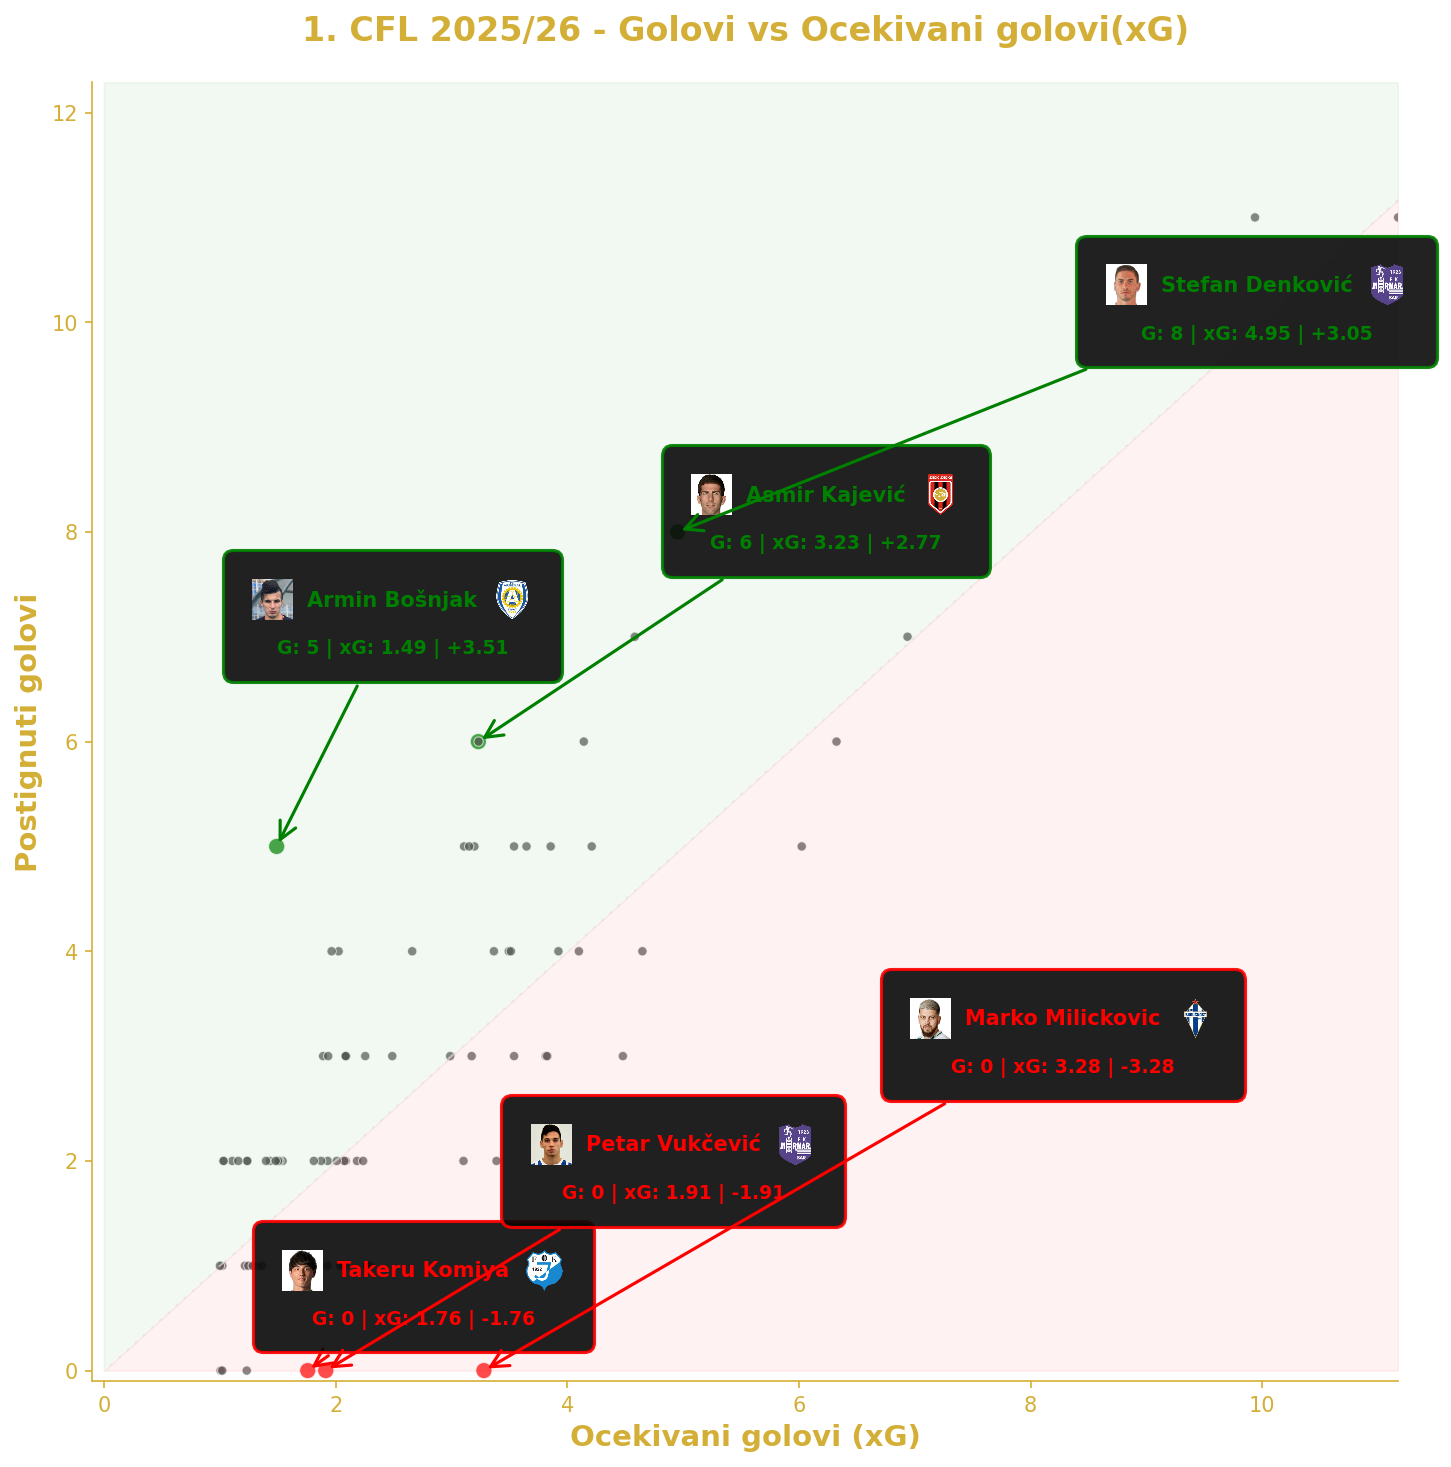

In [2]:

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.offsetbox import (
    OffsetImage, AnnotationBbox, TextArea, HPacker, VPacker
)
import matplotlib.image as mpimg
import pandas as pd

# ─── Figure Setup ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
ax.set_facecolor('none')
fig.patch.set_alpha(0.0)

# ─── Scatter Plot ─────────────────────────────────────────────────
ax.scatter(goals_xg_plot['xG'], goals_xg_plot['Goals'],
           c=goals_xg_plot['Color'], s=goals_xg_plot['Size'] * 20,
           alpha=0.7, edgecolors='white', linewidth=0.5)

max_val = max(goals_xg_plot['xG'].max(), goals_xg_plot['Goals'].max())
ax.plot([0, max_val], [0, max_val], 'w--', alpha=0.5, linewidth=1)

y_padding = max_val * 0.1
ax.set_ylim(bottom=-0.1, top=max_val + y_padding)
ax.set_xlim(left=-0.1, right=max_val)

x_fill = np.linspace(0, max_val, 100)
ax.fill_between(x_fill, x_fill, max_val + y_padding, color='green', alpha=0.05)
ax.fill_between(x_fill, 0, x_fill, color='red', alpha=0.05)

# ─── Styling ──────────────────────────────────────────────────────
ax.set_xlabel('Ocekivani golovi (xG)', fontsize=14, color='#d4af37', fontweight='bold')
ax.set_ylabel('Postignuti golovi', fontsize=14, color='#d4af37', fontweight='bold')
ax.grid(False)
ax.spines['bottom'].set_color('#d4af37')
ax.spines['left'].set_color('#d4af37')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#d4af37', labelsize=10)
ax.set_title('1. CFL 2025/26 - Golovi vs Ocekivani golovi(xG)',
             fontsize=16, color='#d4af37', fontweight='bold', pad=20)

# ─── Load images ──────────────────────────────────────────────────
team_logos, player_photos = {}, {}
for f in (PROCESSED_DATA_DIR / 'team_logos').glob('*.png'):
    try:    team_logos[int(f.stem)]   = mpimg.imread(f)
    except Exception: pass
for f in (PROCESSED_DATA_DIR / 'player_photos').glob('*.png'):
    try:    player_photos[int(f.stem)] = mpimg.imread(f)
    except Exception: pass
print(f"✅ Loaded {len(team_logos)} team logos, {len(player_photos)} player photos")

# ─── Fixed label zones in data coordinates ────────────────────────
TOP_N = len(top_outperformers)

out_sorted   = top_outperformers.sort_values('xG').reset_index(drop=True)
under_sorted = top_underperformers.sort_values('xG').reset_index(drop=True)

def data_relative_positions(df_sorted, y_offset_base, x_offset=0.0, x_spread=2.0, min_x=0.3, y_stagger=1.2):
    """Place each label close to its data point.
    x_offset shifts all labels right by a fixed amount (use empty chart space).
    Labels at the same Goals value get staggered y-offsets so they
    don't land on the same horizontal line."""
    n = len(df_sorted)

    # Build a map: index → extra y stagger for players sharing the same Goals
    goals_groups = {}
    for i, (_, row) in enumerate(df_sorted.iterrows()):
        g = row['Goals']
        goals_groups.setdefault(g, []).append(i)

    y_extra = {}
    for indices in goals_groups.values():
        cnt = len(indices)
        for k, idx in enumerate(indices):
            # centre the group around 0: -step, 0, +step, ...
            y_extra[idx] = (k - (cnt - 1) / 2) * y_stagger

    positions = []
    for i, (_, row) in enumerate(df_sorted.iterrows()):
        lx = row['xG'] + x_offset + (i - (n - 1) / 2) * x_spread
        lx = max(min_x, lx)
        ly = row['Goals'] + y_offset_base + y_extra[i]
        positions.append((lx, ly))
    return positions

# Outperformer labels: shifted right into the empty upper-right space
out_label_positions = data_relative_positions(
    out_sorted, y_offset_base=+2.2, x_offset=+3.0, x_spread=2.0
)

# Underperformer labels: shifted right into the empty lower-right space
under_label_positions = data_relative_positions(
    under_sorted, y_offset_base=+2.0, x_offset=+3.0, x_spread=2.0
)

# ─── Annotation using HPacker / VPacker ──────────────────────────
def annotate_player(row, label_xy, color):
    pid      = int(row['player_id'])
    lx, ly   = label_xy
    diff_str = f"+{row['Diff']:.2f}" if row['Diff'] >= 0 else f"{row['Diff']:.2f}"

    tp_name  = {'color': color, 'fontsize': 10, 'fontweight': 'bold'}
    tp_stats = {'color': color, 'fontsize':  9, 'fontweight': 'bold'}

    name_ta  = TextArea(row['name'], textprops=tp_name)
    stats_ta = TextArea(
        f"G: {int(row['Goals'])} | xG: {row['xG']:.2f} | {diff_str}",
        textprops=tp_stats
    )

    # Top row: [photo]  name  [logo]
    top_children = []
    if pid in player_photos:
        top_children.append(OffsetImage(player_photos[pid], zoom=0.13))
    top_children.append(name_ta)
    tid = int(row['team_id']) if pd.notna(row.get('team_id')) else None
    if tid and tid in team_logos:
        top_children.append(OffsetImage(team_logos[tid], zoom=0.13))

    top_row  = HPacker(children=top_children, pad=3, sep=7, align='center')
    full_box = VPacker(children=[top_row, stats_ta], pad=6, sep=6, align='center')

    ab = AnnotationBbox(
        full_box,
        (row['xG'], row['Goals']),   # arrow tip → actual data point
        xybox=(lx, ly),              # label centre in data coordinates
        xycoords='data',
        boxcoords='data',
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
        bboxprops=dict(boxstyle='round,pad=0.5', facecolor='#0a0a0a',
                       edgecolor=color, alpha=0.9, linewidth=1.5),
        frameon=True,
        box_alignment=(0.5, 0.5),
    )
    ax.add_artist(ab)

for i, (_, row) in enumerate(out_sorted.iterrows()):
    annotate_player(row, out_label_positions[i], 'green')

for i, (_, row) in enumerate(under_sorted.iterrows()):
    annotate_player(row, under_label_positions[i], 'red')

# ─── Save ─────────────────────────────────────────────────────────
plt.tight_layout(pad=1.5)
figures_dir = Path('..') / 'outputs' / LEAGUE / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
output_path = figures_dir / 'polutka_lab_goals_vs_xg_post.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight',
            transparent=True, edgecolor='none')
print(f'\n✅ Figure saved to: {output_path}')
plt.show()


In [3]:
# League-wide xG vs Goals Analysis
print('='*60)
print('1. CFL 2025/26 - League-wide Goals vs Expected Goals (xG)')
print('='*60)

# Calculate total xG and goals across the entire league
total_xg = shots_all_df['xg'].sum()
total_goals = shots_all_df['isGoal'].sum()
difference = total_goals - total_xg
percentage_diff = (difference / total_xg) * 100

print(f'\n📊 Overall League Statistics:')
print(f'   Total Expected Goals (xG): {total_xg:.2f}')
print(f'   Total Actual Goals:        {total_goals}')
print(f'   Difference:                {difference:+.2f}')
print(f'   Percentage Difference:     {percentage_diff:+.2f}%')

if difference > 0:
    print(f'\n✅ The league is OVERPERFORMING xG by {abs(difference):.2f} goals ({abs(percentage_diff):.2f}%)')
elif difference < 0:
    print(f'\n📉 The league is UNDERPERFORMING xG by {abs(difference):.2f} goals ({abs(percentage_diff):.2f}%)')
else:
    print(f'\n🎯 The league is performing exactly at xG expectations')

# Calculate conversion rate
total_shots = len(shots_all_df)
actual_conversion = (total_goals / total_shots) * 100
expected_conversion = (total_xg / total_shots) * 100

print(f'\n🎯 Conversion Rates:')
print(f'   Expected Conversion Rate: {expected_conversion:.2f}%')
print(f'   Actual Conversion Rate:   {actual_conversion:.2f}%')

print('='*60)

1. CFL 2025/26 - League-wide Goals vs Expected Goals (xG)

📊 Overall League Statistics:
   Total Expected Goals (xG): 296.84
   Total Actual Goals:        316
   Difference:                +19.16
   Percentage Difference:     +6.45%

✅ The league is OVERPERFORMING xG by 19.16 goals (6.45%)

🎯 Conversion Rates:
   Expected Conversion Rate: 11.04%
   Actual Conversion Rate:   11.76%


In [4]:
# =============================================================================
# Team-level xG vs Goals Analysis
# =============================================================================

print('\n' + '='*60)
print('Team Performance Analysis - Goals vs Expected Goals (xG)')
print('='*60)

# Aggregate shots by team (group by team_id only to avoid duplicates)
team_stats = (
    shots_all_df
    .groupby('team_id')
    .agg(
        xG=('xg', 'sum'),
        Goals=('isGoal', 'sum'),
        Shots=('xg', 'count')
    )
    .reset_index()
)

# Add canonical team names from teams_meta
team_stats['Team'] = team_stats['team_id'].map(team_name_map)

# Load league standings for ordering
standings_path = PROCESSED_DATA_DIR / 'league_standings.csv'
if standings_path.exists():
    standings_df = pd.read_csv(standings_path, usecols=['team_id', 'position'])
    team_stats = team_stats.merge(standings_df, on='team_id', how='left')
    team_stats = team_stats.rename(columns={'position': 'Position'})
else:
    print(f"⚠️ Standings file not found. Using performance-based ordering.")
    team_stats['Position'] = np.nan

# Calculate performance metrics
team_stats['Diff'] = team_stats['Goals'] - team_stats['xG']
team_stats['Diff_Pct'] = (team_stats['Diff'] / team_stats['xG']) * 100
team_stats['Conversion_Rate'] = (team_stats['Goals'] / team_stats['Shots']) * 100
team_stats['Expected_Conversion'] = (team_stats['xG'] / team_stats['Shots']) * 100

# Sort by performance difference
team_stats_by_diff = team_stats.sort_values('Diff', ascending=False).reset_index(drop=True)
team_stats_by_position = team_stats.sort_values('Position', na_position='last').reset_index(drop=True)
team_stats_sorted = team_stats_by_diff.copy()

# Display team statistics
print(f'\n📊 Team Statistics (sorted by performance vs xG):')
print('-'*60)

for _, row in team_stats_sorted.iterrows():
    team_name = row['Team'] if pd.notna(row['Team']) else f"Team {int(row['team_id'])}"
    perf_indicator = '✅' if row['Diff'] > 0 else ('📉' if row['Diff'] < 0 else '🎯')
    
    print(f"\n{perf_indicator} {team_name}")
    print(f"   Goals: {int(row['Goals'])} | xG: {row['xG']:.2f} | Diff: {row['Diff']:+.2f} ({row['Diff_Pct']:+.1f}%)")
    print(f"   Conversion: {row['Conversion_Rate']:.2f}% (Expected: {row['Expected_Conversion']:.2f}%)")

# Summary
top_overperformer = team_stats_sorted.iloc[0]
top_underperformer = team_stats_sorted.iloc[-1]

print('\n' + '='*60)
print(f'🏆 Best Overperformer: {top_overperformer["Team"]} (+{top_overperformer["Diff"]:.2f} goals, +{top_overperformer["Diff_Pct"]:.1f}%)')
print(f'📉 Biggest Underperformer: {top_underperformer["Team"]} ({top_underperformer["Diff"]:.2f} goals, {top_underperformer["Diff_Pct"]:.1f}%)')
print('='*60)

# Create summary table
team_summary = team_stats_sorted[['Team', 'Goals', 'xG', 'Diff', 'Diff_Pct', 'Conversion_Rate']].copy()
team_summary.columns = ['Team', 'Goals', 'xG', 'Difference', 'Diff %', 'Conv %']
team_summary = team_summary.round(2)

print('\n📋 Complete Team Summary Table:')
display(team_summary)


Team Performance Analysis - Goals vs Expected Goals (xG)

📊 Team Statistics (sorted by performance vs xG):
------------------------------------------------------------

✅ FK Dečić Tuzi
   Goals: 33 | xG: 24.35 | Diff: +8.65 (+35.5%)
   Conversion: 15.49% (Expected: 11.43%)

✅ OFK Petrovac
   Goals: 35 | xG: 28.73 | Diff: +6.27 (+21.8%)
   Conversion: 11.55% (Expected: 9.48%)

✅ FK Sutjeska Nikšić
   Goals: 42 | xG: 36.04 | Diff: +5.96 (+16.5%)
   Conversion: 14.19% (Expected: 12.17%)

✅ FK Budućnost Podgorica
   Goals: 33 | xG: 30.46 | Diff: +2.54 (+8.3%)
   Conversion: 11.38% (Expected: 10.50%)

✅ FK Jezero
   Goals: 32 | xG: 30.34 | Diff: +1.66 (+5.5%)
   Conversion: 11.99% (Expected: 11.36%)

✅ FK Bokelj Kotor
   Goals: 29 | xG: 27.73 | Diff: +1.27 (+4.6%)
   Conversion: 13.68% (Expected: 13.08%)

✅ Mladost DG
   Goals: 33 | xG: 31.99 | Diff: +1.01 (+3.2%)
   Conversion: 12.31% (Expected: 11.94%)

📉 FK Arsenal Tivat
   Goals: 20 | xG: 20.00 | Diff: -0.00 (-0.0%)
   Conversion: 9.30

,Team,Goals,xG,Difference,Diff %,Conv %
0,FK Dečić Tuzi,33,24.35,8.65,35.53,15.49
1,OFK Petrovac,35,28.73,6.27,21.81,11.55
2,FK Sutjeska Nikšić,42,36.04,5.96,16.55,14.19
3,FK Budućnost Podgorica,33,30.46,2.54,8.35,11.38
4,FK Jezero,32,30.34,1.66,5.46,11.99
5,FK Bokelj Kotor,29,27.73,1.27,4.57,13.68
6,Mladost DG,33,31.99,1.01,3.16,12.31
7,FK Arsenal Tivat,20,20.00,-0.00,-0.01,9.30
8,FK Mornar Bar,33,33.08,-0.08,-0.26,12.41
9,FK Jedinstvo Bijelo Polje,18,24.06,-6.06,-25.18,7.17


✅ Loaded 12 team logos
✅ Figure 1 saved to: ..\outputs\cg\figures\team_goals_vs_xg_comparison.png


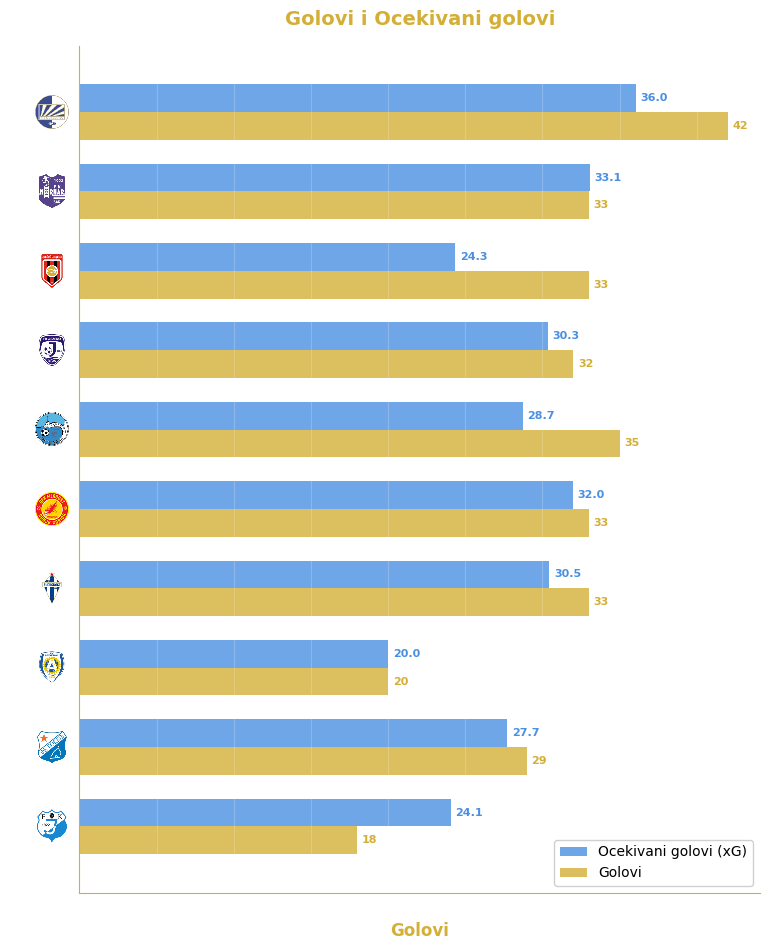

✅ Figure 2 saved to: ..\outputs\cg\figures\team_xg_performance_difference.png


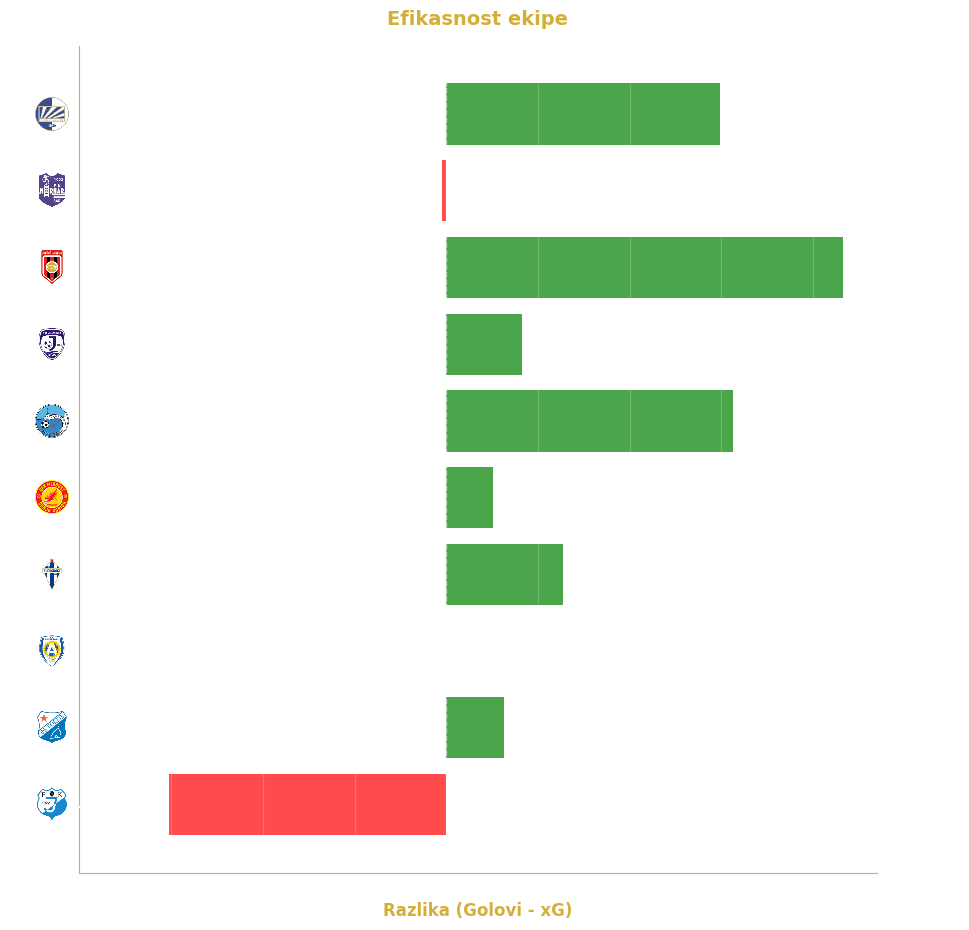

In [5]:
# =============================================================================
# Visualize Team Performance - Goals vs xG
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Use standings order when available, otherwise performance order
if 'team_stats_by_position' in globals() and not team_stats_by_position.empty:
    team_viz = team_stats_by_position.copy()
else:
    team_viz = team_stats_sorted.copy()

team_viz = team_viz.reset_index(drop=True)
x_pos = np.arange(len(team_viz))

# Create position labels
if 'Position' in team_viz.columns and team_viz['Position'].notna().any():
    fallback_positions = pd.Series(np.arange(1, len(team_viz) + 1), index=team_viz.index)
    pos_labels = team_viz['Position'].fillna(fallback_positions)
else:
    pos_labels = pd.Series(np.arange(1, len(team_viz) + 1), index=team_viz.index)
pos_labels = pos_labels.astype(int).astype(str) + '. '

# Load team logos
team_logos = {}
logos_dir = PROCESSED_DATA_DIR / 'team_logos'
if logos_dir.exists():
    for logo_file in logos_dir.glob('*.png'):
        try:
            tid = int(logo_file.stem)
            team_logos[tid] = mpimg.imread(logo_file)
        except Exception as e:
            print(f"⚠️ Could not load logo {logo_file}: {e}")

print(f"✅ Loaded {len(team_logos)} team logos")

def add_team_logos(ax, y_positions, team_ids, labels, x_offset_text=-50, x_offset_logo=-20, zoom=0.16):
    """Attach team position text and logos next to y-axis ticks."""
    if not team_logos:
        return
    
    for y, team_id, label in zip(y_positions, team_ids, labels):
        # Add position text
        ax.annotate(
            label, xy=(0, y), xycoords=('axes fraction', 'data'),
            xytext=(x_offset_text, 0), textcoords='offset points',
            ha='left', va='center', fontsize=10, color='white', fontweight='bold'
        )
        
        # Add team logo
        if pd.isna(team_id):
            continue
        try:
            tid = int(team_id)
        except (TypeError, ValueError):
            continue
        
        logo_img = team_logos.get(tid)
        if logo_img is None:
            continue
        
        imagebox = OffsetImage(logo_img, zoom=zoom)
        ab = AnnotationBbox(
            imagebox, (0, y), xycoords=('axes fraction', 'data'),
            xybox=(x_offset_logo, 0), boxcoords='offset points',
            frameon=False, pad=0
        )
        ax.add_artist(ab)

# =============================================================================
# FIGURE 1: Goals vs xG Comparison
# =============================================================================

fig1, ax1 = plt.subplots(figsize=(10, 10))
fig1.patch.set_alpha(0.0)
bar_width = 0.35

# Create bars
bars1 = ax1.barh(x_pos - bar_width/2, team_viz['xG'], bar_width, 
                 label='Ocekivani golovi (xG)', color='#4a90e2', alpha=0.8)
bars2 = ax1.barh(x_pos + bar_width/2, team_viz['Goals'], bar_width, 
                 label='Golovi', color='#d4af37', alpha=0.8)

# Add value labels
for bar, val in zip(bars1, team_viz['xG']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}', ha='left', va='center', fontsize=8, 
             color='#4a90e2', fontweight='bold')

for bar, val in zip(bars2, team_viz['Goals']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{int(val)}', ha='left', va='center', fontsize=8, 
             color='#d4af37', fontweight='bold')

# Styling
ax1.set_yticks(x_pos)
ax1.set_yticklabels([''] * len(team_viz))
ax1.tick_params(axis='y', length=0)
ax1.set_xlabel('Golovi', fontsize=12, color='#d4af37', fontweight='bold')
ax1.set_title('Golovi i Ocekivani golovi', fontsize=14, color='#d4af37', fontweight='bold', pad=15)
ax1.legend(loc='lower right', framealpha=0.9)
ax1.set_facecolor('none')
ax1.grid(axis='x', alpha=0.2, color='white')
ax1.tick_params(axis='x', colors='white')
ax1.spines['bottom'].set_color('#d4af37')
ax1.spines['left'].set_color('#d4af37')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.invert_yaxis()

add_team_logos(ax1, x_pos, team_viz['team_id'], pos_labels)

plt.tight_layout(rect=[0.22, 0.02, 1, 0.98])

# Save
figures_dir = Path('..') / 'outputs' / LEAGUE / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
output_path = figures_dir / 'team_goals_vs_xg_comparison.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', 
            transparent=True, edgecolor='none')
print(f'✅ Figure 1 saved to: {output_path}')
plt.show()

# =============================================================================
# FIGURE 2: Performance Difference
# =============================================================================

fig2, ax2 = plt.subplots(figsize=(10, 10))
fig2.patch.set_alpha(0.0)

colors = ['green' if x > 0 else 'red' for x in team_viz['Diff']]
bars = ax2.barh(x_pos, team_viz['Diff'], color=colors, alpha=0.7)

# Add value labels
for bar, val, pct in zip(bars, team_viz['Diff'], team_viz['Diff_Pct']):
    width = bar.get_width()
    label_x = width + 0.3 if width > 0 else width - 0.3
    ha = 'left' if width > 0 else 'right'
    ax2.text(label_x, bar.get_y() + bar.get_height()/2, 
             f'{val:+.1f} ({pct:+.1f}%)', 
             ha=ha, va='center', fontsize=9, color='white', fontweight='bold')

# Styling
ax2.set_yticks(x_pos)
ax2.set_yticklabels([''] * len(team_viz))
ax2.tick_params(axis='y', length=0)
ax2.set_xlabel('Razlika (Golovi - xG)', fontsize=12, color='#d4af37', fontweight='bold')
ax2.set_title('Efikasnost ekipe', fontsize=14, color='#d4af37', fontweight='bold', pad=15)
ax2.axvline(x=0, color='white', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlim(left=-8, right=None)
ax2.set_facecolor('none')
ax2.grid(axis='x', alpha=0.2, color='white')
ax2.tick_params(axis='x', colors='white')
ax2.spines['bottom'].set_color('#d4af37')
ax2.spines['left'].set_color('#d4af37')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.invert_yaxis()

add_team_logos(ax2, x_pos, team_viz['team_id'], pos_labels)

plt.tight_layout(rect=[0.02, 0.04, 1, 0.98])

# Save
output_path = figures_dir / 'team_xg_performance_difference.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', 
            transparent=True, edgecolor='none')
print(f'✅ Figure 2 saved to: {output_path}')
plt.show()

In [6]:
# ─── Instagram Post Composition ─────────────────────────────
from PIL import Image

ASSETS_DIR = Path('..') / 'assets'
FINAL_DIR = Path('..') / 'outputs' / LEAGUE / 'final_posts'
FINAL_DIR.mkdir(parents=True, exist_ok=True)
INSTAGRAM_SIZE = (1080, 1350)
SAFE_ZONE = {'left': 30, 'top': 250, 'right': 1050, 'bottom': 1270}

for fig_name in ["polutka_lab_goals_vs_xg_post.png", "team_goals_vs_xg_comparison.png", "team_xg_performance_difference.png"]:
    chart_path = figures_dir / fig_name
    if not chart_path.exists():
        print(f"Skipping {fig_name} (not found)")
        continue

    background = Image.open(ASSETS_DIR / 'background.png').convert('RGBA')
    if background.size != INSTAGRAM_SIZE:
        background = background.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)

    chart = Image.open(chart_path).convert('RGBA')
    safe_w = SAFE_ZONE['right'] - SAFE_ZONE['left']
    safe_h = SAFE_ZONE['bottom'] - SAFE_ZONE['top']
    chart = chart.resize((safe_w, safe_h), Image.Resampling.LANCZOS)
    background.paste(chart, (SAFE_ZONE['left'], SAFE_ZONE['top']), chart)

    out_path = FINAL_DIR / fig_name
    background.convert('RGB').save(out_path, quality=95)
    print(f"Saved: {out_path}")



Saved: ..\outputs\cg\final_posts\polutka_lab_goals_vs_xg_post.png
Saved: ..\outputs\cg\final_posts\team_goals_vs_xg_comparison.png
Saved: ..\outputs\cg\final_posts\team_xg_performance_difference.png
